# **1- import libraries**

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns

In [2]:
df = pd.read_csv('census_income.csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47568,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,0
47569,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,0
47570,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,0
47571,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,0


In [4]:
df['income'] = df['income'].str.strip()

df['income'] = df['income'].apply(
    lambda x: 1 if x == '>50K' or x == '>50K.' else 0
)

AttributeError: Can only use .str accessor with string values!

In [5]:
df['income'].value_counts()

,count
income,
0,36038
1,11535


In [6]:
df.shape

(47573, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47573 entries, 0 to 47572
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             47573 non-null  int64 
 1   workclass       47573 non-null  object
 2   fnlwgt          47573 non-null  int64 
 3   education       47573 non-null  object
 4   education-num   47573 non-null  int64 
 5   marital-status  47573 non-null  object
 6   occupation      47573 non-null  object
 7   relationship    47573 non-null  object
 8   race            47573 non-null  object
 9   sex             47573 non-null  object
 10  capital-gain    47573 non-null  int64 
 11  capital-loss    47573 non-null  int64 
 12  hours-per-week  47573 non-null  int64 
 13  native-country  47573 non-null  object
 14  income          47573 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 5.4+ MB


In [8]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [9]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
count,47573.000000,4.757300e+04,47573.000000,47573.000000,47573.000000,47573.000000,47573.000000
mean,38.648771,1.897319e+05,10.091628,1092.238581,87.942131,40.603998,0.242469
std,13.556990,1.055829e+05,2.567288,7490.924415,404.204740,12.261040,0.428581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175850e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.782820e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.377130e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


# **2- check missing & duplications**

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dropna(inplace = True)

In [13]:
df.drop_duplicates(inplace = True)

# Visualization

Text(0.5, 1.0, 'Income Label Distribution')

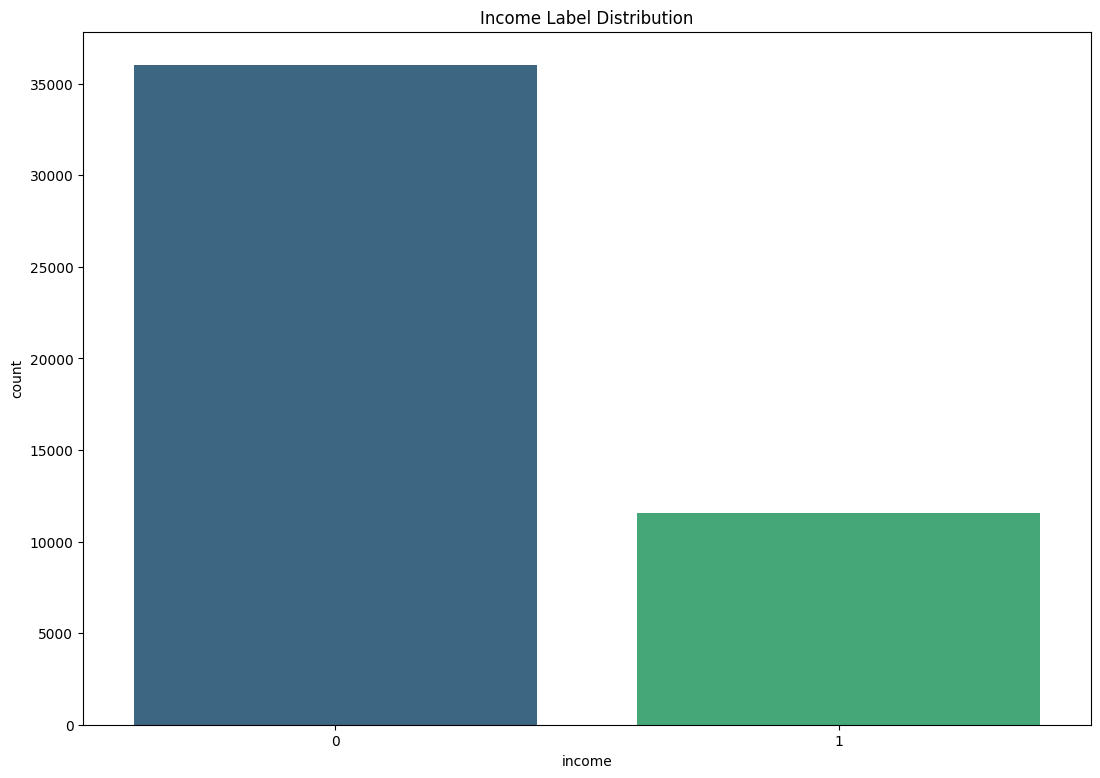

In [16]:
fig, axes = plt.subplots(figsize=(13, 9))

sns.countplot(data=df, x='income', hue='income', palette='viridis', legend=False)
axes.set_title('Income Label Distribution')

Text(0.5, 1.0, 'Age Distribution')

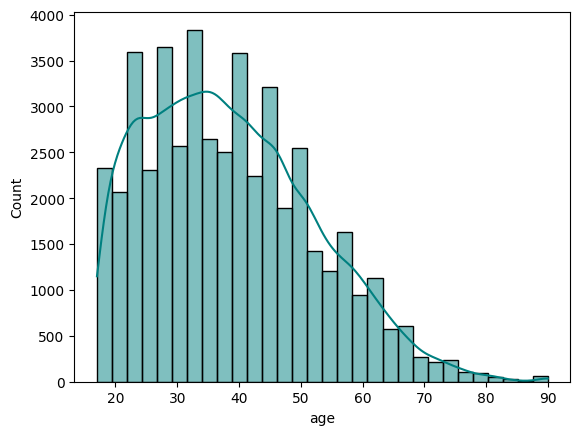

In [17]:
sns.histplot(df['age'], bins=30, kde=True, color='teal')
axes.set_title('Age Distribution')


Text(0.5, 1.0, 'Hours-per-Week Distribution')

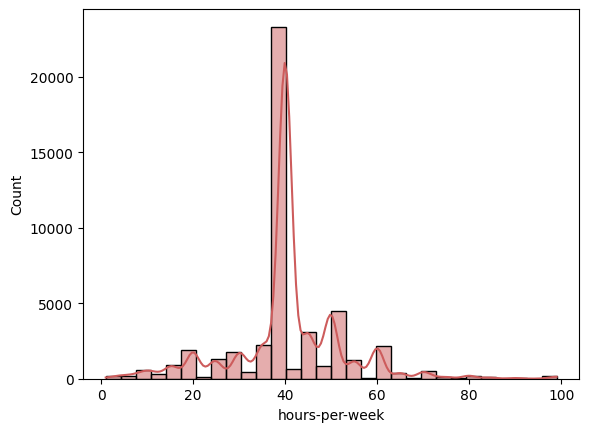

In [18]:
sns.histplot(df['hours-per-week'], bins=30, kde=True, color='indianred')
axes.set_title('Hours-per-Week Distribution')


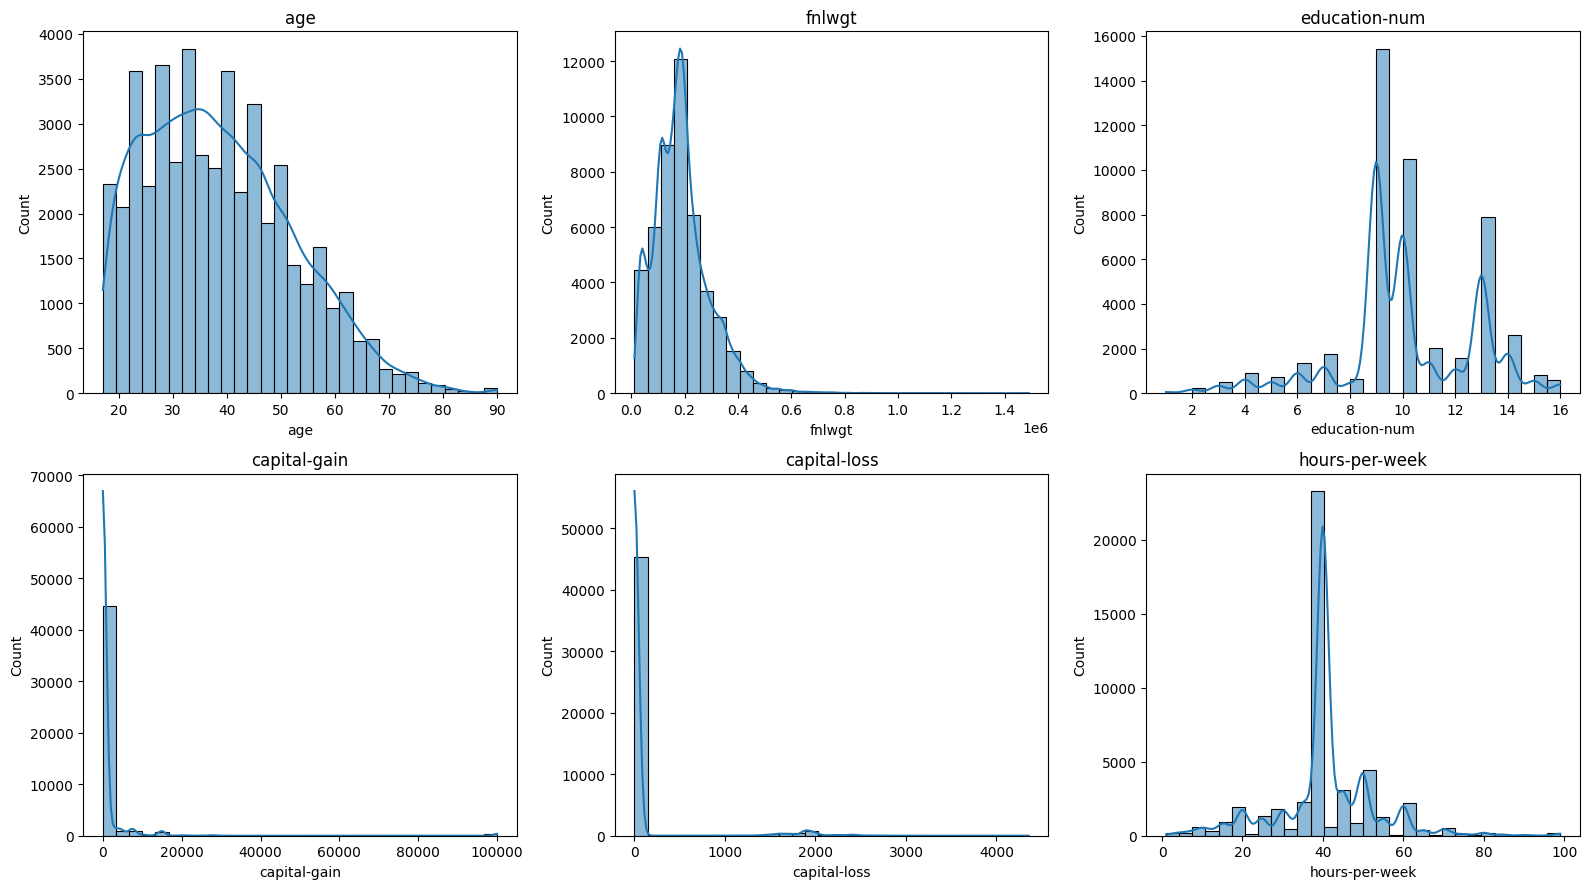

In [20]:
numeric_cols_census = df.select_dtypes(include=['int64']).columns
fig, axes = plt.subplots(2,3,figsize=(16, 9))
for ax, col in zip(axes.ravel(),numeric_cols_census):
    sns.histplot(df[col],bins=30,kde=True,ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [22]:
categorical_cols_eda = df.select_dtypes(include="object").columns.tolist()
print(categorical_cols_eda)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


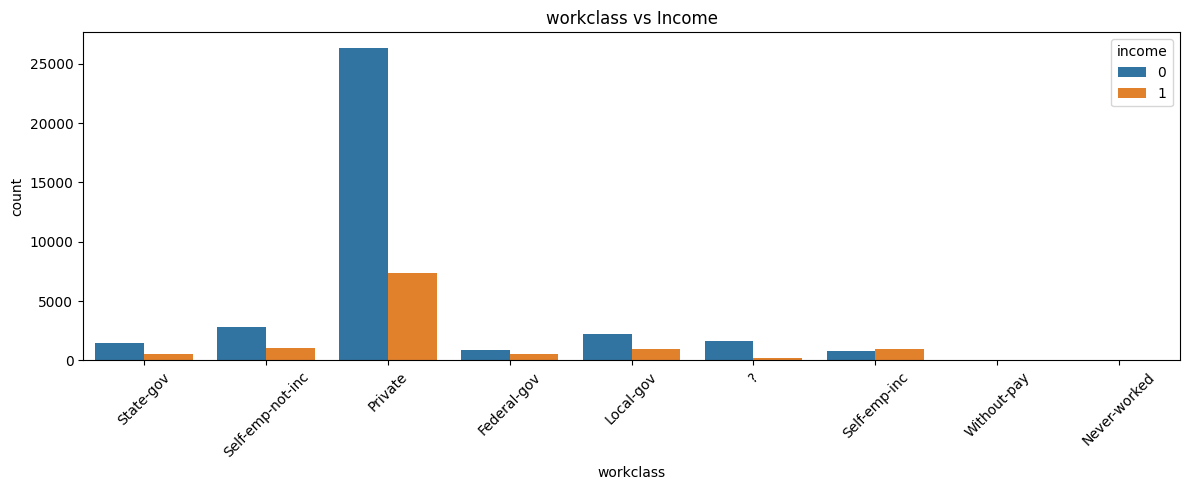

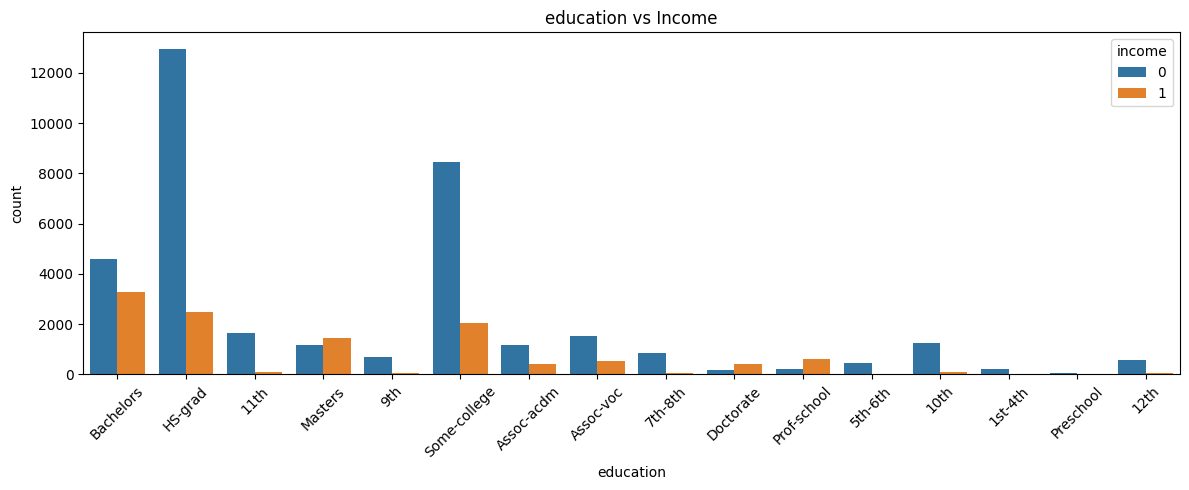

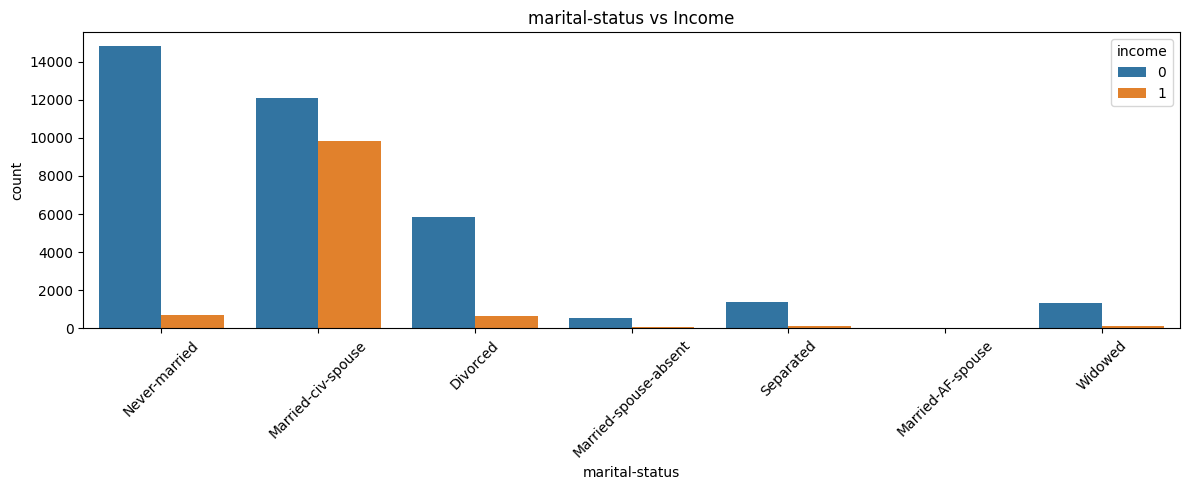

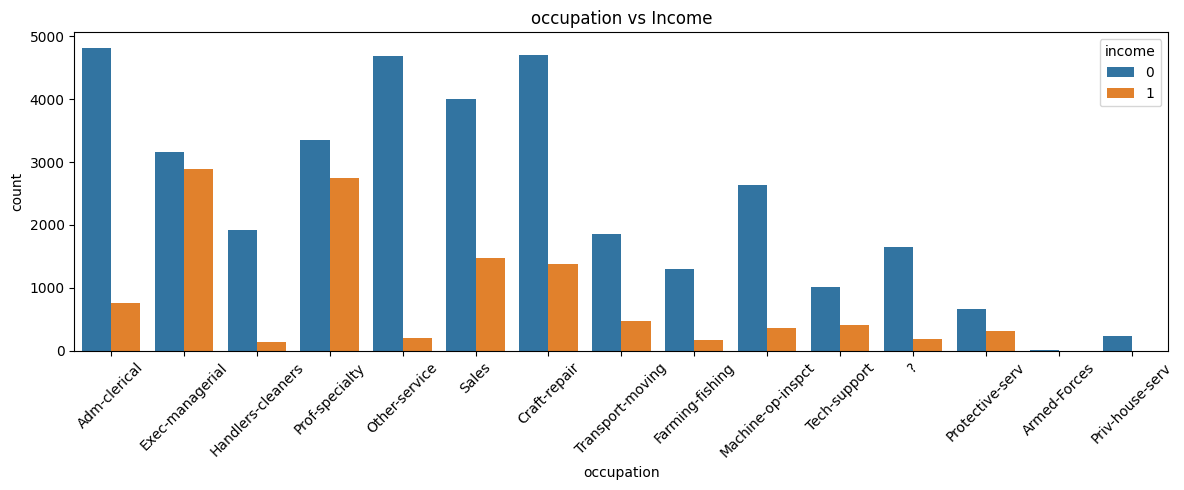

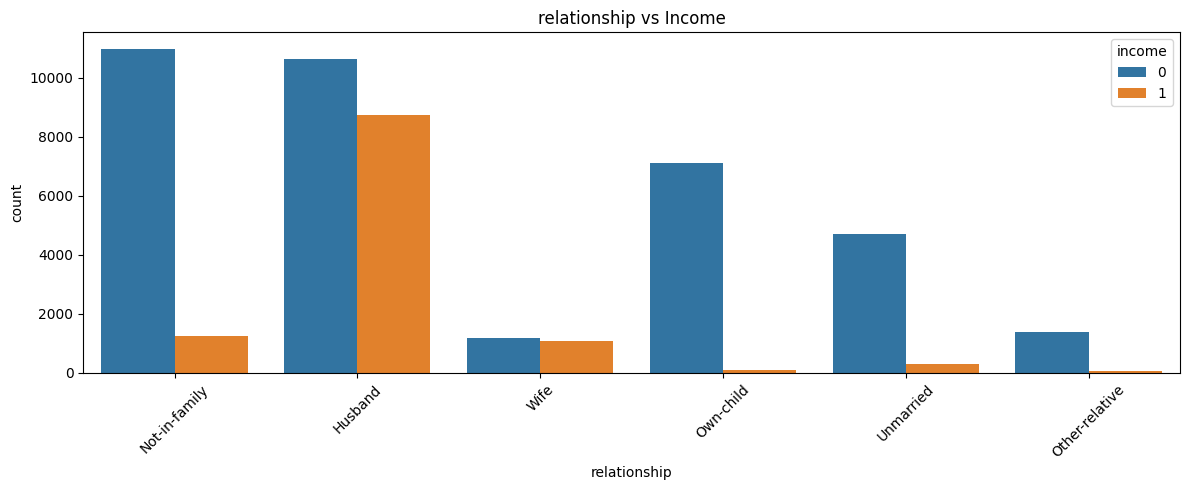

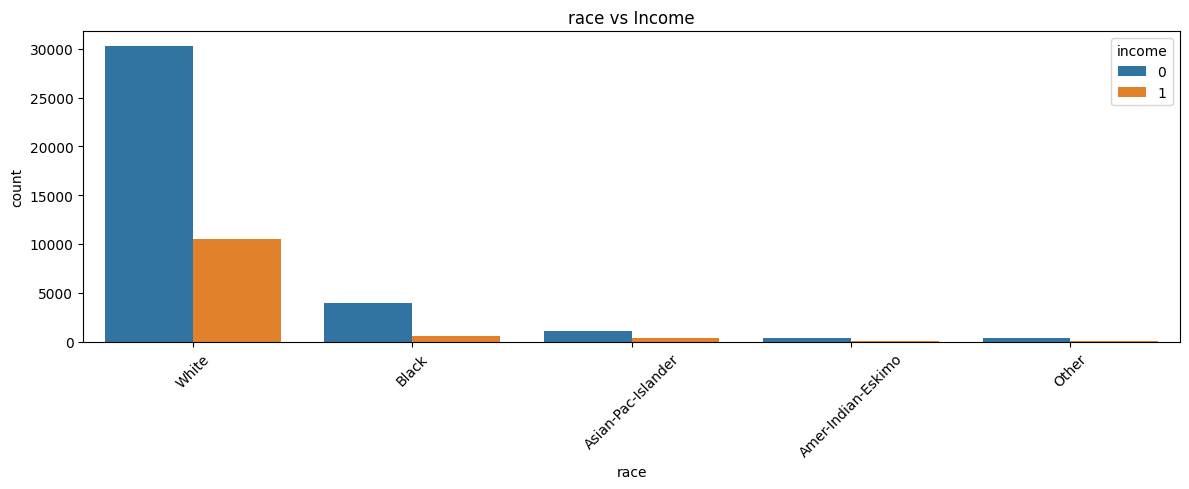

In [23]:
for col in categorical_cols_eda[:6]:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df,x=col,hue="income")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Income")
    plt.tight_layout()
    plt.show()

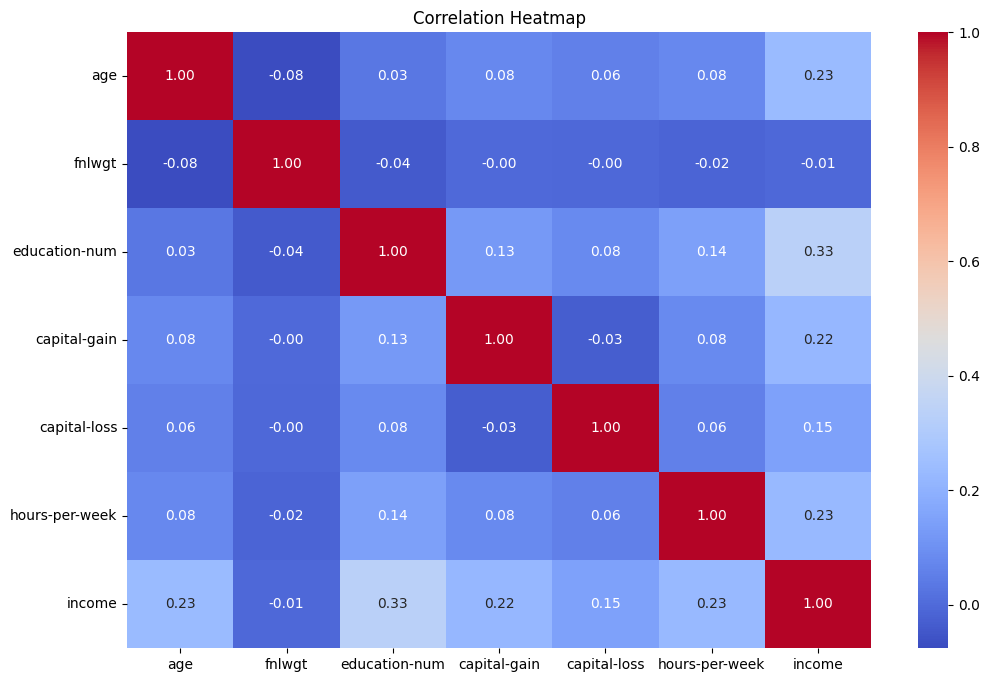

In [26]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
df.to_csv('census_income.csv', index=False, encoding='utf-8-sig')

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Encoding

In [29]:
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0


# Scaling

In [30]:
X = df.drop('income', axis = 1)
y = df['income']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
scaler = StandardScaler()

# Fit ONLY on training data
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

In [33]:
# Use the same scaler on test data
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
df['income'].value_counts()

,count
income,
0,36038
1,11535


# UnderSampling

In [36]:
!pip install imblearn
from imblearn.under_sampling import RandomUnderSampler

In [37]:
rus = RandomUnderSampler(random_state=42)

X_resampled, y_resampled = rus.fit_resample(X, y)

# Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print('Best Parameters:', grid_lr.best_params_)
print('Best F1 Score:', grid_lr.best_score_)

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best F1 Score: 0.8232697364691823


# KNeighborsClassifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print('Best Parameters:', grid_knn.best_params_)
print('Best F1 Score:', grid_knn.best_score_)

# SVC

In [ ]:
from sklearn.svm import SVC

model = SVC()

params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': [0.01, 0.1]
}

grid_svc = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svc.fit(X_train, y_train)

print('Best Parameters:', grid_svc.best_params_)
print('Best F1 Score:', grid_svc.best_score_)

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print('Best Parameters:', grid_dt.best_params_)
print('Best F1 Score:', grid_dt.best_score_)

# RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

params = {
    'n_estimators': [100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print('Best Parameters:', grid_rf.best_params_)
print('Best F1 Score:', grid_rf.best_score_)

# GaussianNB

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

params = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

grid_nb = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)

print('Best Parameters:', grid_nb.best_params_)
print('Best F1 Score:', grid_nb.best_score_)

# GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=42)

params = {
    'n_estimators': [150, 200, 250],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 5, 6],
    'min_samples_leaf': [1, 2, 4]
}

grid_gb = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print('Best Parameters:', grid_gb.best_params_)
print('Best F1 Score:', grid_gb.best_score_)

# MLPClassifier

In [ ]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    max_iter=1000,
    random_state=42
)

params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_mlp = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_mlp.fit(X_train, y_train)

print('Best Parameters:', grid_mlp.best_params_)
print('Best F1 Score:', grid_mlp.best_score_)

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier(
    random_state=42
)

params = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_leaf_nodes': [15, 31, 63],
    'l2_regularization': [0, 0.1, 1]
}

grid_hgb = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=2
)

grid_hgb.fit(X_train, y_train)

print('Best Parameters:', grid_hgb.best_params_)
print('Best F1 Score:', grid_hgb.best_score_)

In [39]:
pip install xgboost

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=2
)

grid_xgb.fit(X_train, y_train)

print('Best Parameters:', grid_xgb.best_params_)
print('Best F1 Score:', grid_xgb.best_score_)

In [ ]:
pip install catboost

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

params = {
    'iterations': [200, 300, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

grid_cat = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_cat.fit(X_train, y_train)

print('Best Parameters:', grid_cat.best_params_)
print('Best F1 Score:', grid_cat.best_score_)

In [41]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300,
    subsample=1.0,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [42]:
y_pred = xgb_model.predict(X_test)

In [43]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8716763005780347
Precision: 0.7819314641744548
Recall: 0.6527958387516255
F1 Score: 0.7115520907158044

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      7208
           1       0.78      0.65      0.71      2307

    accuracy                           0.87      9515
   macro avg       0.84      0.80      0.81      9515
weighted avg       0.87      0.87      0.87      9515



In [44]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6788  420]
 [ 801 1506]]


In [45]:
X.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country']

In [ ]:
user_data = {
    'age': 35,
    'workclass': 'Private',
    'fnlwgt': 180000,
    'education': 'Bachelors',
    'education-num': 13,
    'marital-status': 'Married-civ-spouse',
    'occupation': 'Exec-managerial',
    'relationship': 'Husband',
    'race': 'White',
    'sex': 'Male',
    'capital-gain': 0,
    'capital-loss': 0,
    'hours-per-week': 40,
    'native-country': 'United-States'
}

X_user = pd.DataFrame([user_data])

In [ ]:
for col, le in label_encoders.items():
    X_user[col] = le.transform(X_user[col].astype(str))

In [ ]:
X_user = pd.DataFrame(
    scaler.transform(X_user),
    columns=X_user.columns
)

In [ ]:
probability = xgb_model.predict_proba(X_user)[0][1]

print(f"Income Probability: {probability:.2%}")

In [ ]:
def predict_income(user_data):
    X_user = pd.DataFrame([user_data])
    for col, le in label_encoders.items():
        X_user[col] = le.transform(X_user[col].astype(str))
    X_user = X_user[X.columns]
    X_user = pd.DataFrame(
        scaler.transform(X_user),
        columns=X_user.columns
    )
    probability = xgb_model.predict_proba(X_user)[0][1]

    return probability

In [ ]:
cars_df = pd.read_csv("data.csv")

In [ ]:
def get_affordable_cars(probability, cars_df):

    if probability < 0.20:
        max_bin = 0.0

    elif probability < 0.40:
        max_bin = 0.2

    elif probability < 0.60:
        max_bin = 0.4

    elif probability < 0.80:
        max_bin = 0.6

    else:
        max_bin = 0.8

    affordable_cars = cars_df[
        cars_df['price_bin'] <= max_bin
    ].copy()

    return affordable_cars

In [ ]:
def filter_cars(
    cars_df,
    brand=None,
    model=None,
    min_year=None,
    condition=None,
    fuel_type=None,
    color=None,
    location=None
):

    filtered = cars_df.copy()

    if brand:
        filtered = filtered[filtered['brand'] == brand]

    if model:
        filtered = filtered[filtered['model'] == model]

    if min_year:
        filtered = filtered[filtered['year'] >= min_year]

    if condition:
        filtered = filtered[filtered['condition'] == condition]

    if fuel_type:
        filtered = filtered[filtered['fuel_type'] == fuel_type]

    if color:
        filtered = filtered[filtered['color'] == color]

    if location:
        filtered = filtered[filtered['location'] == location]

    return filtered

In [ ]:
import pickle

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

with open("label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

cars_df.to_csv("cars.csv", index=False)

In [ ]:
import os

print(os.listdir())

In [ ]:
from google.colab import files
files.download("scaler.pkl")
files.download("label_encoders.pkl")


In [ ]:
import xgboost

print(xgboost.__version__)

In [ ]:
xgb_model.save_model("model.json")

In [ ]:
files.download("model.json")